In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
%matplotlib inline

In [ ]:
plt.rcParams["figure.figsize"] = (12, 9)

# Read Data


In [ ]:
wine_data = load_wine()

wine_df = pd.DataFrame(data=wine_data.data, columns=wine_data.feature_names)

wine_df["target"] = wine_data.target
wine_df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


<Axes: xlabel='features', ylabel='value'>

/home/arman/Documents/arman/Uni/Master/Master these 2025/tube-geometry-prediction/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 8.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


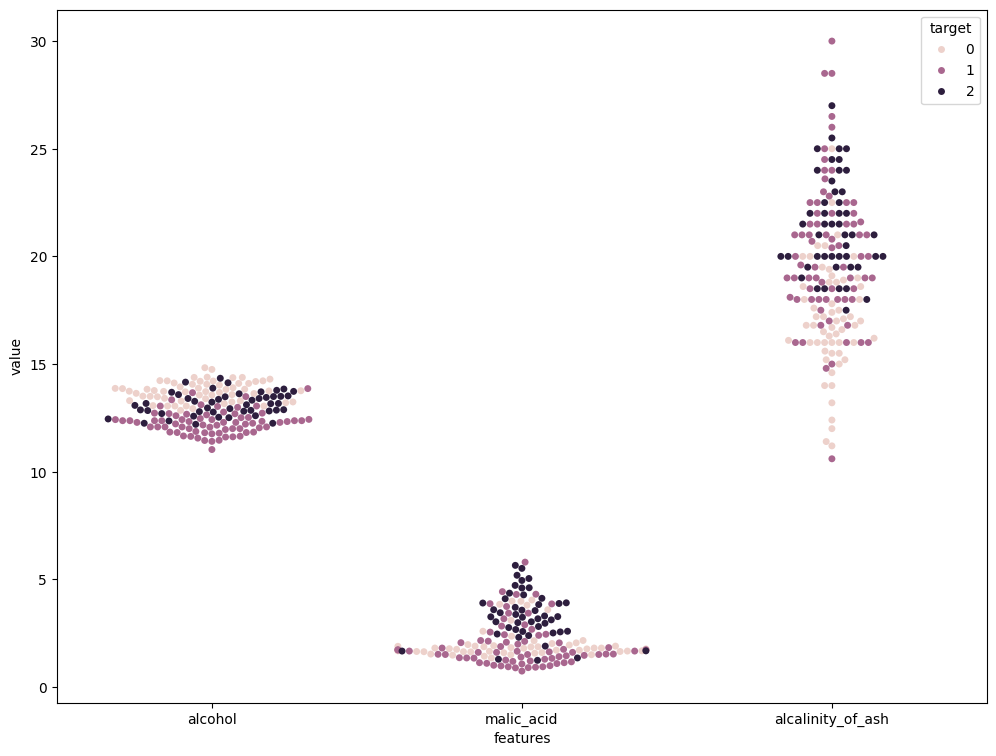

In [ ]:
from seaborn import swarmplot

data_to_plot = pd.melt(
    wine_df[["alcohol", "malic_acid", "alcalinity_of_ash", "target"]],
    id_vars="target",
    var_name="features",
    value_name="value",
)

swarmplot(data=data_to_plot, x="features", y="value", hue="target")

In [ ]:
wine_df["target"].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

# Train/Test spliting


In [17]:
from sklearn.model_selection import train_test_split

X = wine_df.drop(["target"], axis=1)
y = wine_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((124, 13), (54, 13))

# Function to train and calculate the f1 score

In [32]:
from sklearn.metrics import f1_score
def train_and_predict(gbc, X, y, X_test)-> float:
    gbc.fit(X, y)
    preds = gbc.predict(X_test)
    f1_score_all = round(f1_score(y_test, preds, average='weighted'),3)
    return f1_score_all

# Baseline model:Gradient Boosting Classifier with all features

In [43]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize classifier
gbc =GradientBoostingClassifier(max_depth=5, random_state=42)

f1_score_all = train_and_predict(gbc=gbc, X=X_train,y=y_train, X_test=X_test)
print(f1_score_all)

0.908


# Variance threshold
if its 0, then we habe a feature with constant value and its not predictive

In [35]:
X_train_v1, X_test_v1, y_train_v1, y_test_v1 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy() 

In [36]:
X_train_v1.var(axis=0)

alcohol                             0.658341
malic_acid                          1.123507
ash                                 0.072433
alcalinity_of_ash                  11.471279
magnesium                         232.071532
total_phenols                       0.393226
flavanoids                          0.912299
nonflavanoid_phenols                0.013873
proanthocyanins                     0.335108
color_intensity                     5.669722
hue                                 0.052891
od280/od315_of_diluted_wines        0.470021
proline                         94906.710923
dtype: float64

In [37]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_X_train_v1 = scaler.fit_transform(X_train_v1)

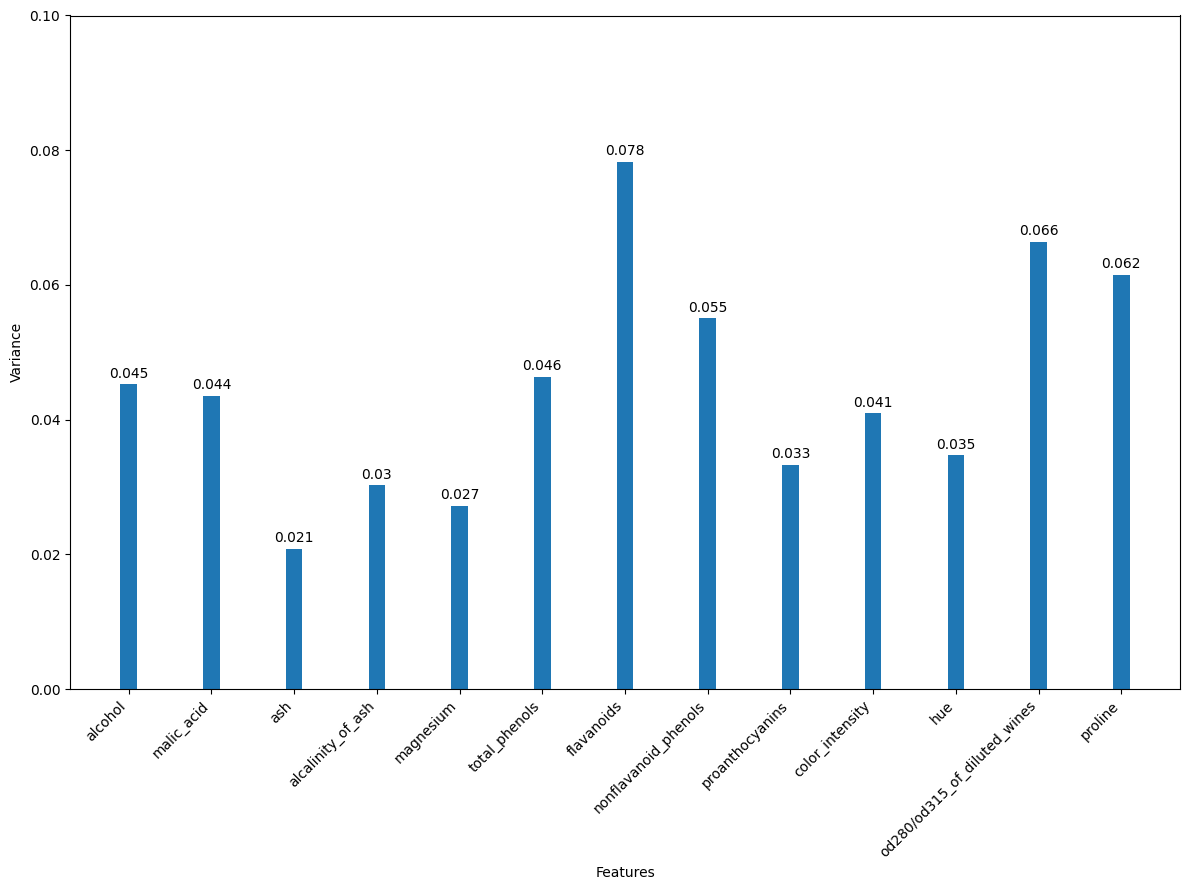

In [38]:
fig, ax = plt.subplots()

x = X.columns
y = scaled_X_train_v1.var(axis=0)

# Use numeric positions for the bars
positions = range(len(x))
ax.bar(positions, y, width=0.2)
ax.set_xticks(positions)
ax.set_xticklabels(x, rotation=45, ha='right')  # rotate labels for readability
ax.set_xlabel('Features')
ax.set_ylabel('Variance')
ax.set_ylim(0, 0.1)

# Add text labels above bars
for pos, value in zip(positions, y):
    ax.text(pos, value + 0.001, str(round(value, 3)), ha='center')

plt.tight_layout()
plt.show()


In [42]:
sel_X_train_v1 = X_train_v1.drop(['ash', 'magnesium'], axis=1)
sel_X_test_v1 = X_test_v1.drop(['ash', 'magnesium'], axis=1)
f1_score_var = train_and_predict(gbc=gbc, X=sel_X_train_v1,y=y_train, X_test=sel_X_test_v1)
print(f1_score_var)

0.963


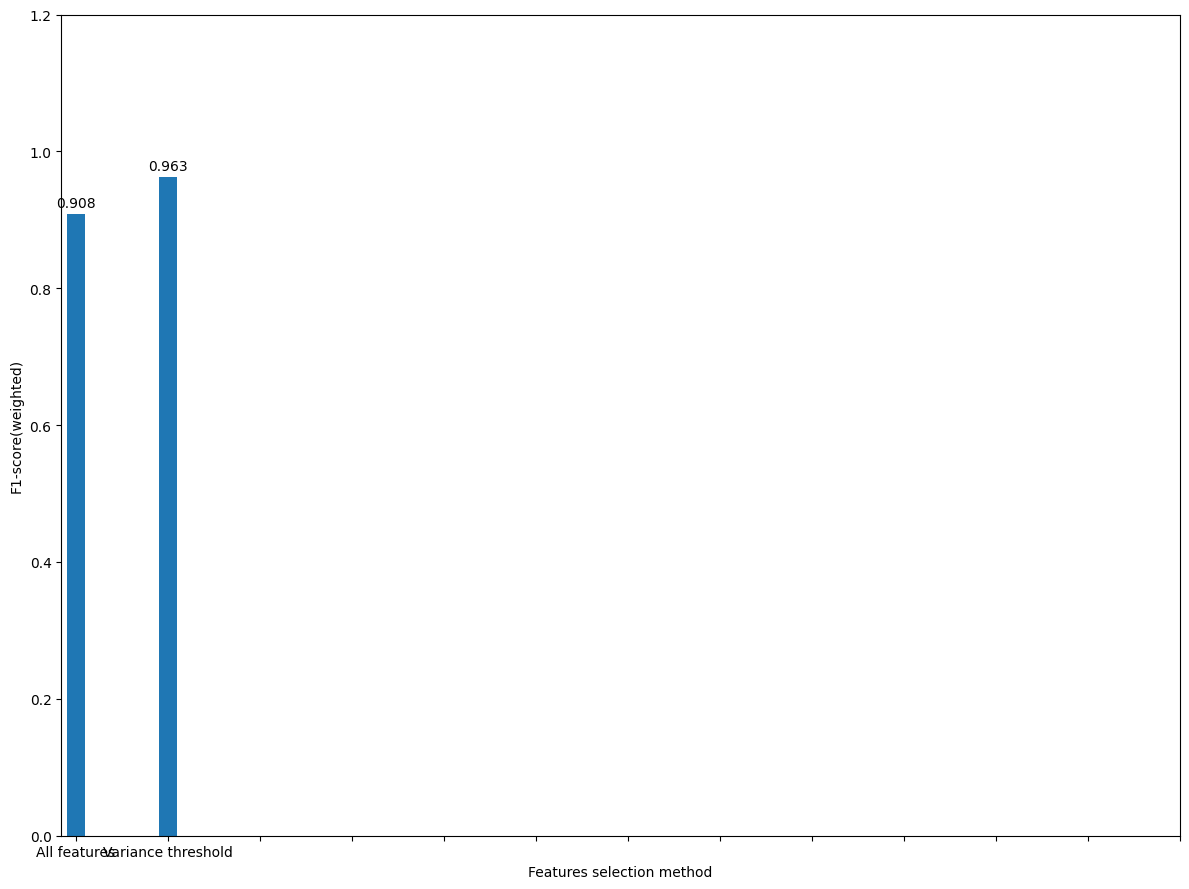

In [46]:
fig, ax = plt.subplots()

x = ['All features', 'Variance threshold']
y = [f1_score_all, f1_score_var]

# Use numeric positions for the bars
ax.bar(x, y, width=0.2)
ax.set_xticks(positions)
ax.set_xlabel('Features selection method')
ax.set_ylabel('F1-score(weighted)')
ax.set_ylim(0, 1.2)

# Add text labels above bars
for index, value in zip(positions, y):
    ax.text(x=index, y=value + 0.01, s=str(round(value, 3)), ha='center')

plt.tight_layout()


# K-best
## Statistical Tests and Metrics for Feature and Target Types

|              | **features****Categorical**            | **features****Numerical**               |
|--------------|--------------------------------------------|---------------------------------------------|
| **target****Categorical** | Chi squaredMutual information           | t-testMutual information               |
| **target****Numerical**   | t-testMutual information                | Pearson correlationSpearman’s rank correlationMutual information |


Mutual information said how many i know from my feature about my target

useful when my dataset is not too big if its big see the recursive method

In [50]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy() 

In [52]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif

f1_score_list = []

for k in range(1,14):
    selector = SelectKBest(mutual_info_classif, k= k)
    selector.fit(X_train_v2, y_train_v2)
    
    sel_X_train_v2 = selector.transform(X_train_v2)
    sel_X_test_v2 = selector.transform(X_test_v2)
    
    f1_score_kbest = train_and_predict(gbc,sel_X_train_v2,y_train_v2,sel_X_test_v2)
    f1_score_list.append(f1_score_kbest)

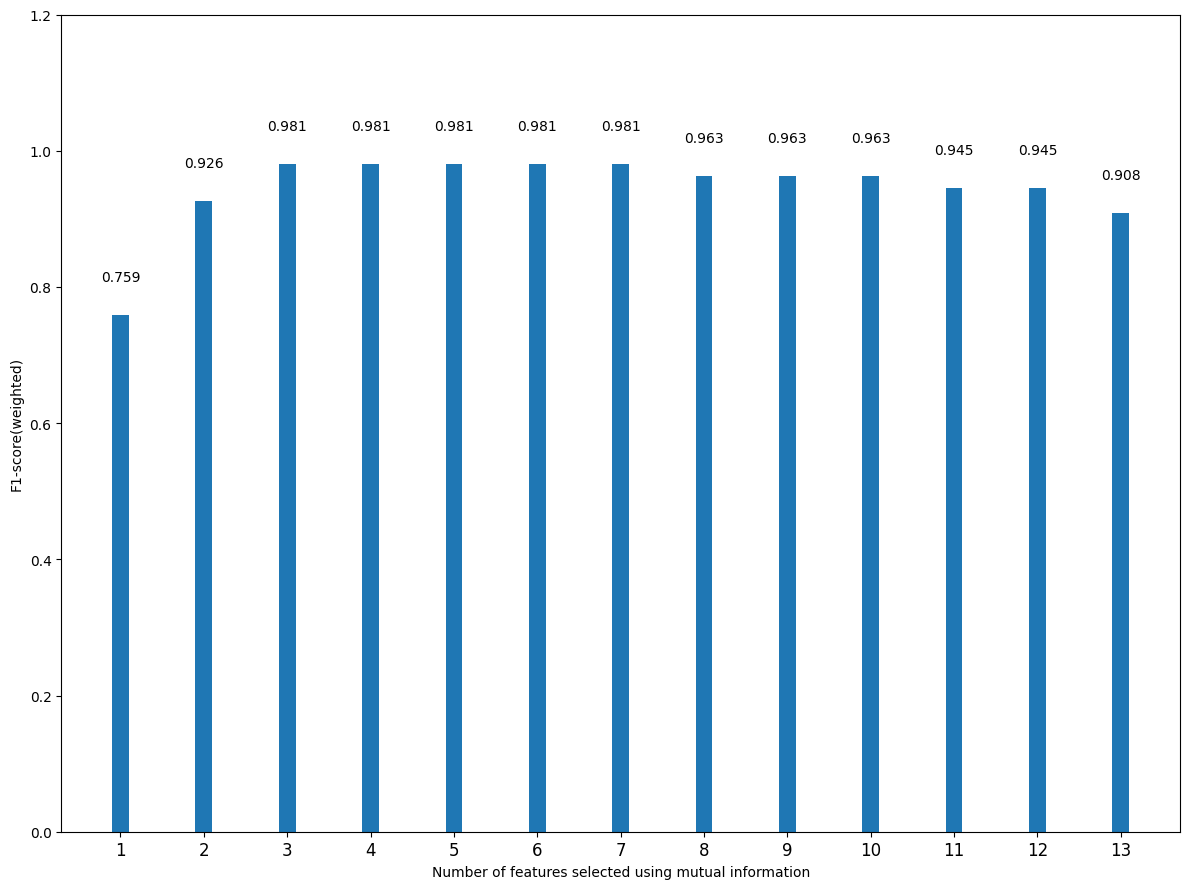

In [59]:
fig, ax = plt.subplots()

x = np.arange(1,14)
y = f1_score_list

# Use numeric positions for the bars
ax.bar(x, y, width=0.2)
ax.set_xlabel('Number of features selected using mutual information')
ax.set_ylabel('F1-score(weighted)')
ax.set_ylim(0, 1.2)
ax.set_xticks(np.arange(1,14))
ax.set_xticklabels(np.arange(1,14), fontsize=12)

# Add text labels above bars
for index, value in enumerate(y):
    ax.text(x[index], value + 0.05, str(value), ha='center')

plt.tight_layout()


In [60]:
selector = SelectKBest(mutual_info_classif, k=3)
selector.fit(X_train_v2,y_train_v2)
selected_feature_mask = selector.get_support()
selected_features = X_train_v2.columns[selected_feature_mask]
selected_features

Index(['flavanoids', 'color_intensity', 'proline'], dtype='object')

# Recursive feature elimination(RFE)

tree based models

In [61]:
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy() 

In [62]:
from sklearn.feature_selection import RFE

rfe_f1_score_list = []

for k in range(1,14):
    RFE_selector = RFE(estimator=gbc, n_features_to_select=k, step=1)
    RFE_selector.fit(X_train_v3, y_train_v3)
    
    sel_X_train_v3 = RFE_selector.transform(X_train_v3)
    sel_X_test_v3 = RFE_selector.transform(X_test_v3)
    
    f1_score_rfe = train_and_predict(gbc,sel_X_train_v3,y_train_v3,sel_X_test_v3)
    rfe_f1_score_list.append(f1_score_rfe)

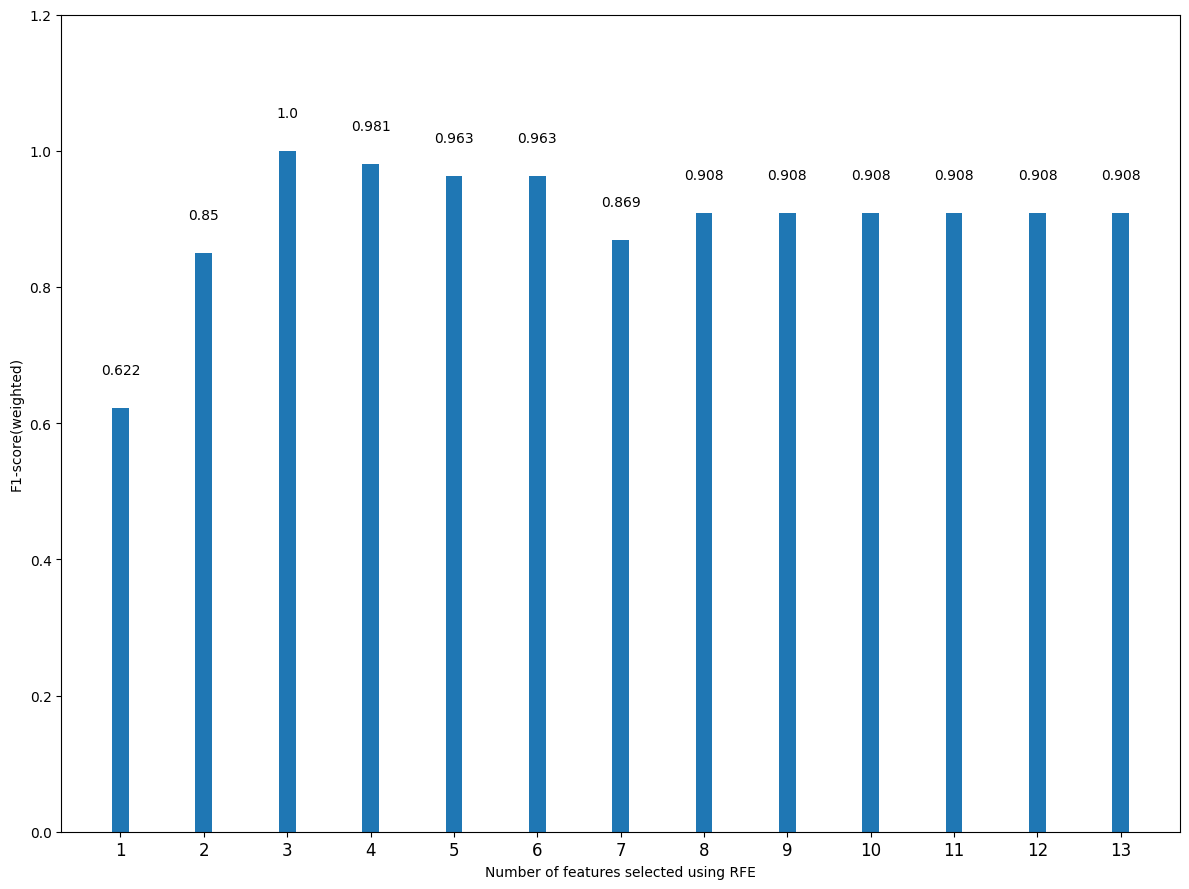

In [63]:
fig, ax = plt.subplots()

x = np.arange(1,14)
y = rfe_f1_score_list

# Use numeric positions for the bars
ax.bar(x, y, width=0.2)
ax.set_xlabel('Number of features selected using RFE')
ax.set_ylabel('F1-score(weighted)')
ax.set_ylim(0, 1.2)
ax.set_xticks(np.arange(1,14))
ax.set_xticklabels(np.arange(1,14), fontsize=12)

# Add text labels above bars
for index, value in enumerate(y):
    ax.text(x[index], value + 0.05, str(value), ha='center')

plt.tight_layout()


In [66]:
RFE_selector = RFE(estimator=gbc, n_features_to_select=3, step=10)
RFE_selector.fit(X_train_v3,y_train_v3)
selected_feature_mask = RFE_selector.get_support()
selected_features = X_train_v3.columns[selected_feature_mask]
selected_features

Index(['color_intensity', 'od280/od315_of_diluted_wines', 'proline'], dtype='object')

# Boruta
Take the human out
1. Create shadow features: randomly shuffled verson of each feature
2. Compute the importance of each shadow feature- the highes score becomes out threshold
3. If the importance of the original feature is higher than the threshold-keep otherwise discard

In [67]:
X_train_v4, X_test_v4, y_train_v4, y_test_v4 = X_train.copy(), X_test.copy(), y_train.copy(), y_test.copy() 

In [70]:
from boruta import BorutaPy

boruta_selector = BorutaPy(gbc, random_state=42)

# Convert to numpy arrays before fitting
X_train_np = X_train_v4.values
y_train_np = y_train_v4.values.ravel()

boruta_selector.fit(X_train_np, y_train_np)
    
# Transform and get selected features as numpy arrays
sel_X_train_v4 = boruta_selector.transform(X_train_np)
sel_X_test_v4 = boruta_selector.transform(X_test_v4.values)

# Get the selected feature names
selected_features = X_train_v4.columns[boruta_selector.support_].tolist()
print(f"Selected features: {selected_features}")

f1_score_boruta = train_and_predict(gbc, sel_X_train_v4, y_train_v4, sel_X_test_v4)

Selected features: ['malic_acid', 'ash', 'magnesium', 'flavanoids', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [71]:
selected_feature_mask = boruta_selector.support_
selected_features = X_train_v4.columns[selected_feature_mask]
selected_features

Index(['malic_acid', 'ash', 'magnesium', 'flavanoids', 'proanthocyanins',
       'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

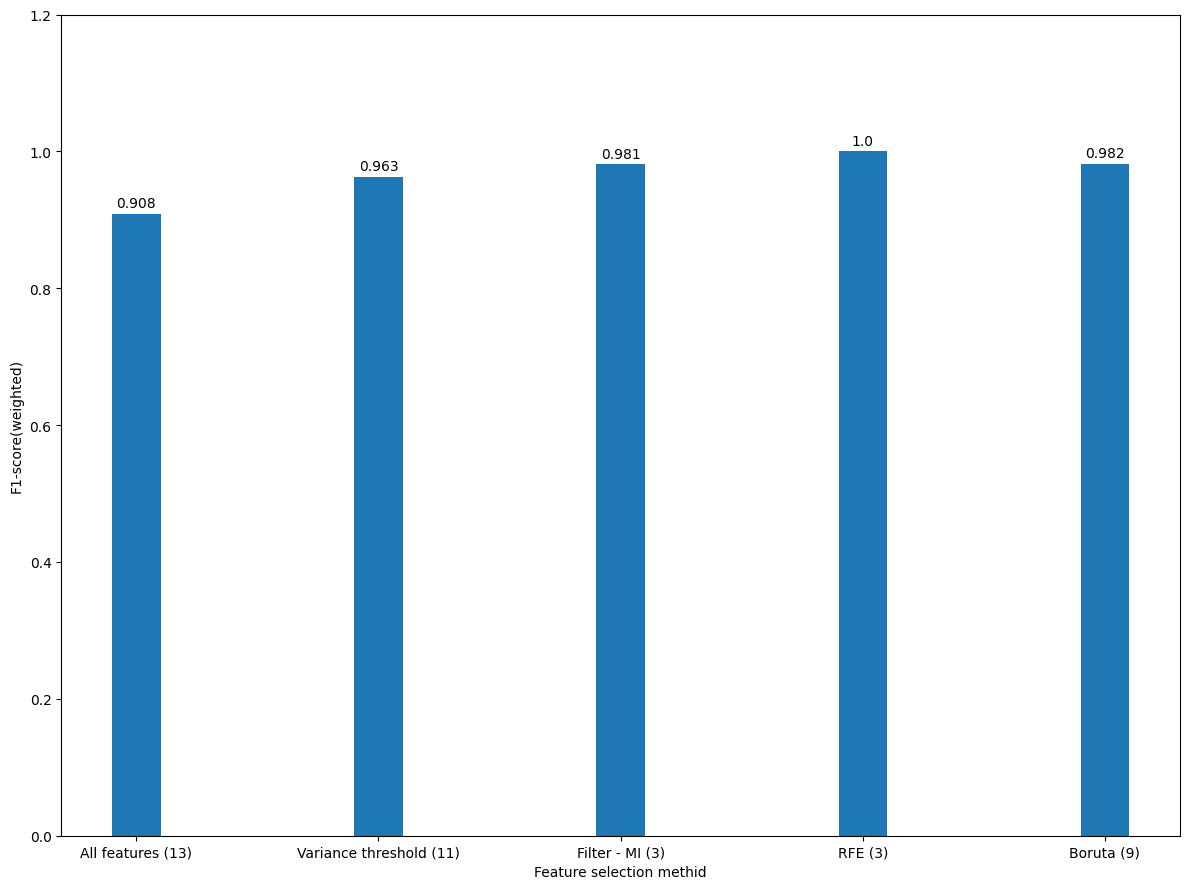

In [72]:
fig, ax = plt.subplots()

x = ["All features (13)", "Variance threshold (11)", "Filter - MI (3)", "RFE (3)", "Boruta (9)"]
y = [f1_score_all, f1_score_var, 0.981, 1.0, f1_score_boruta]

# Use numeric positions for the bars
ax.bar(x, y, width=0.2)
ax.set_xlabel('Feature selection methid')
ax.set_ylabel('F1-score(weighted)')
ax.set_ylim(0, 1.2)

# Add text labels above bars
for index, value in enumerate(y):
    ax.text(index, value + 0.01, str(value), ha='center')

plt.tight_layout()
